In [1]:
# Importing the python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 

In [2]:
cleaned_customer_transaction_data = pd.read_csv(r'C:/Users/USER/Desktop/AMDARI/Fraudulent_Transaction_Detection_For_Finlora_Company/Fraudulent_Transaction_Detection_For_Finlora_Company/Finlora Dataset/artifacts/Cleaned_Data.csv') 

In [3]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette='Spectral'
) 

In [4]:
cleaned_customer_transaction_data.columns 

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

Distribution of Fraud and Transaction Channels

The charts above provide an initial understanding of the dataset and are important for the exploratory data analysis(EDA)stage. The fraud distribution chart is used to examine the balace fraudulent and legistmate transaction. This is particulary important for fraud detection because an inbalanced target variable can cause a machine learning model to favour the majorityclass and perform poorly when identifying fraudulant transactions. Understanding the level of class imbalance helps determine whether tecniques such as class weighting, resampling or appropriae evaluation metrics may be required.

The transaction channel distribution chart shows how transaction are distributed across different channels, such as mobile, online, ATM, or other available channels.Examining this distribution helps identify dominant or underrepresented transaction channels and provides an initial indication of whether the channel may be relevant to fraudulent behaviour. These observations can also guide subsequentfeature analysis and model development. 

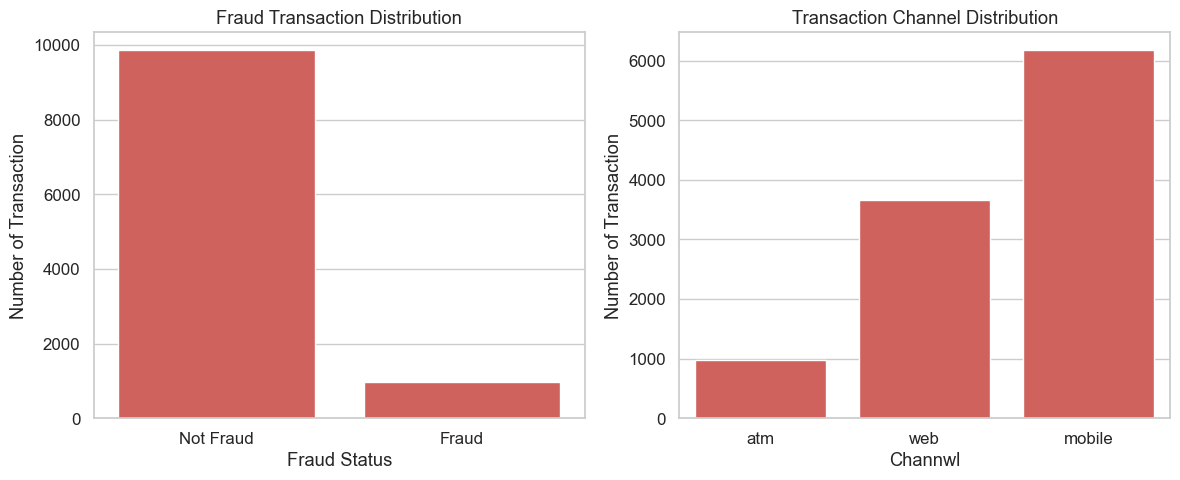

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud distribution
sns.countplot(data=cleaned_customer_transaction_data, x='is_fraud', ax=axes[0])
axes[0].set_title('Fraud Transaction Distribution')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Number of Transaction')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])


# Channel distribution
sns.countplot(data=cleaned_customer_transaction_data, x='channel', ax=axes[1])
axes[1].set_title('Transaction Channel Distribution')
axes[1].set_xlabel('Channwl')
axes[1].set_ylabel('Number of Transaction')

plt.tight_layout()
plt.show() 

IP Country and KYC Tier Analysis

The chart provide an overview of the distribution of transaction across IP countries and KYC tiers, while also examining their relationship with fraudulent transactions. The IP country distribution helps identify the countries from which transaction are predominantly initiated and highlights countries that may be underrepresented in the dataset. Similarly, the KYC tier distribution shows how transactions across disfferent levels of customer verificatio, providing an understanding of the composition of the customerbase.

The IP country versus fraud chart compares fraudulent and legitimate transaction across countries. This is useful for identifying whether fraudulent transactions are concentrated within particular geographic locations, ehich may indicate potential geographic patterns that could be relavent to fraud detection. However, differences in the total number of transaction across countries should be considered when interpreting the results.

The KYC tier verus fraud chart examines the distribution of fraudulent and legistimate transaction across different KYC verification levels. This analysis can help determine whether fraud occurence varies across customer verification tiers and whether KYC ststus may provide useful predictive information for the fraud detection model.

Overall, these visualisation help identify potential patterns and relationships between customer verification, transaction origin, and fraudulent behaviour, which can inform subsequent feature engineering and machine learning model development. 

In [ ]:
Example of 2 row, 2 column

# 0 [[1, 1]]
# 1 [1, 2]]

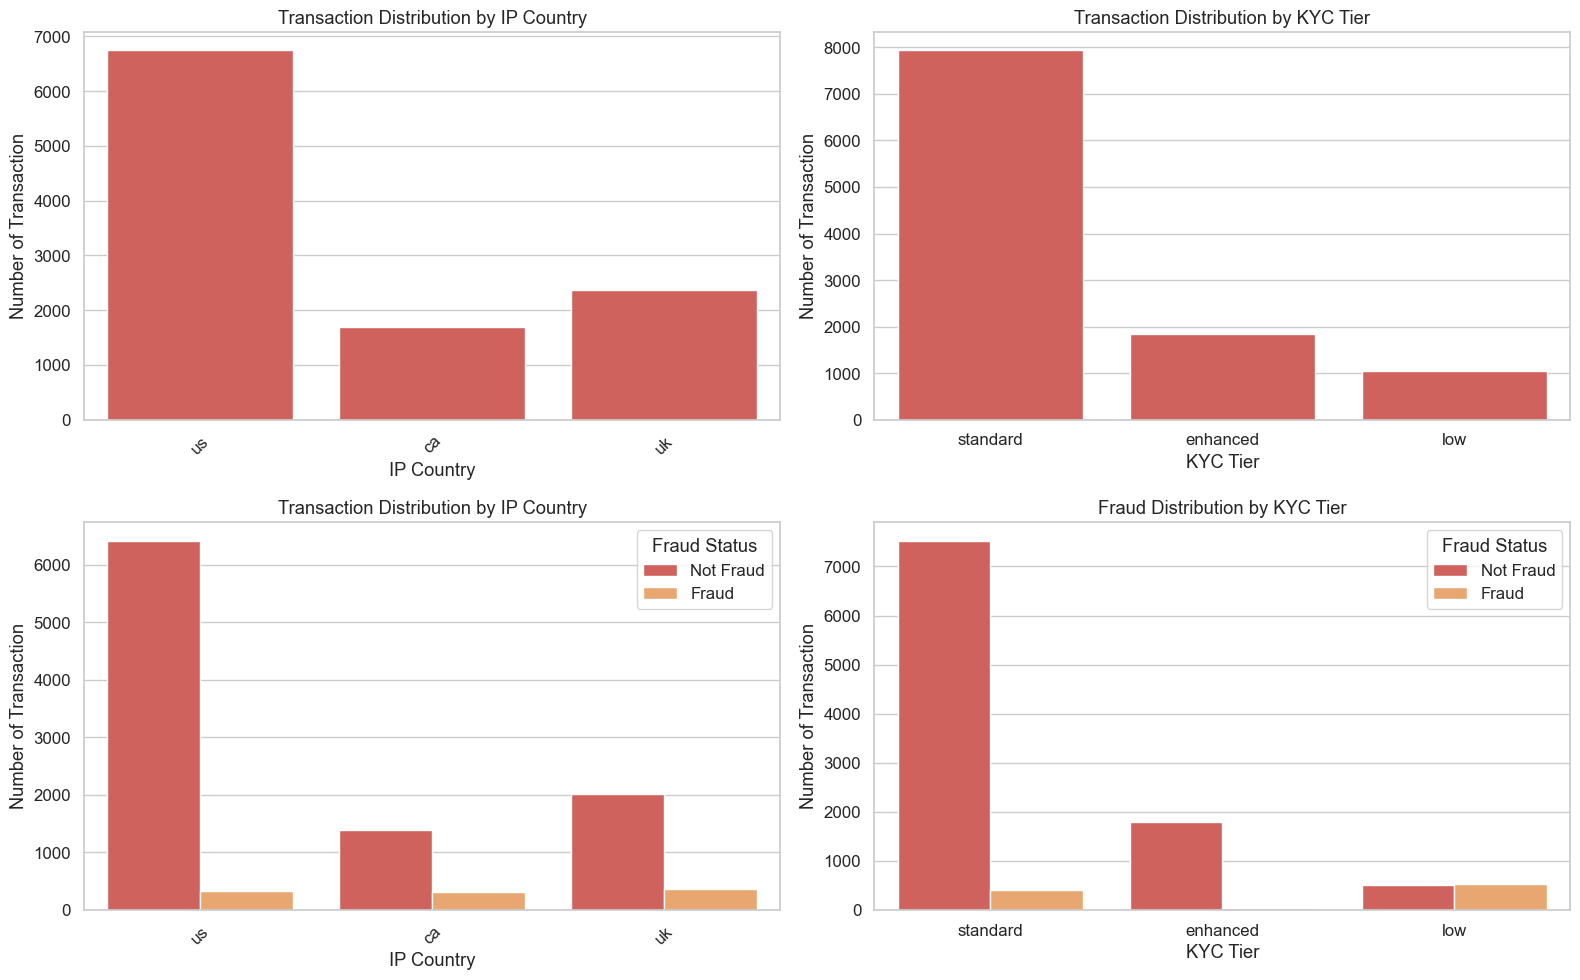

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. IP Country distibution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction Distribution by IP Country')
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transaction')
axes[0, 0].tick_params(axis='x', rotation=45)


# 2. KYC Tier distibution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transaction')


# 3. IP Country vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    hue='is_fraud',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Transaction Distribution by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes[1, 0].set_ylabel('Number of Transaction')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])


# 4. KYC vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    hue='is_fraud',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Distribution by KYC Tier')
axes[1, 1].set_xlabel('KYC Tier')
axes[1, 1].set_ylabel('Number of Transaction')
axes[1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()   

Fraud Rate Analysis by Location Mismatch, KYC Tier, and Transaction Channel

The visualisations show how fraudulent transaction behaviour varies across location mismatch, KYC verification level, and transaction channel. The location mismatch analysis indicates a substantial in fraud risk depending on whether a transaction occurs in an expected location. Transaction where location_mismatch = False, meaning the transaction location is consistent with the user's expected or previously observed location, have a relatively low fraud rate of approximately 3-5%. In contrast, transaction where location_mistmatch = True, indicating an unexpected or unfamilier transaction location, have a consderably higher fraud rate of over 35%. Based on the observed rates, transactions with a location mismatch are approximately 7-9 times more likely to be fraudulent than transaction without a location mismatch. This suggests that location mismatch may be an important predictive feature for identifying potentially fraudulent transactions.

The analysis of KYC tier also shows differences i fraud risk across customer verification levels. The resuld indicate that customers with ower evel of KYC verifiation have higher fraud rates, while customers with enhances verification have the lowest observed fraud risk. This suggest that the level of customer verification may provide useful information for distingushing between legitimate and potentially fraudulent transactions.

The transaction channel analysis provides two complementary perspective. Thefraud-rate chart measures the proportion of transaction that are fraudulent within each channel, while the fraud-count chart measures the actual number of fradulent and non-fraudulent transaction. The results indicate web transaction have a higher fraud rate than mobile transaction. suggesting that the web channel may present a relatively higher fraud risk.

However, fraud counts should be interpreted alongside fraud rates because differences in the toatal number of transactionns across channels can influence the absolute number of fraudulent transactions.

Overall, these findings indicate that location mismatch, KYC verification leel and transaction channelmay contain meaningful for fraud detction. These variable should therfore be considered during feature engineering and model development, while their predictive importanve should ultimately be validated using statistical analysis and machine learning model evelua tion.

C:\Users\USER\AppData\Local\Temp\ipykernel_24944\51660160.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_24944\51660160.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_24944\51660160.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


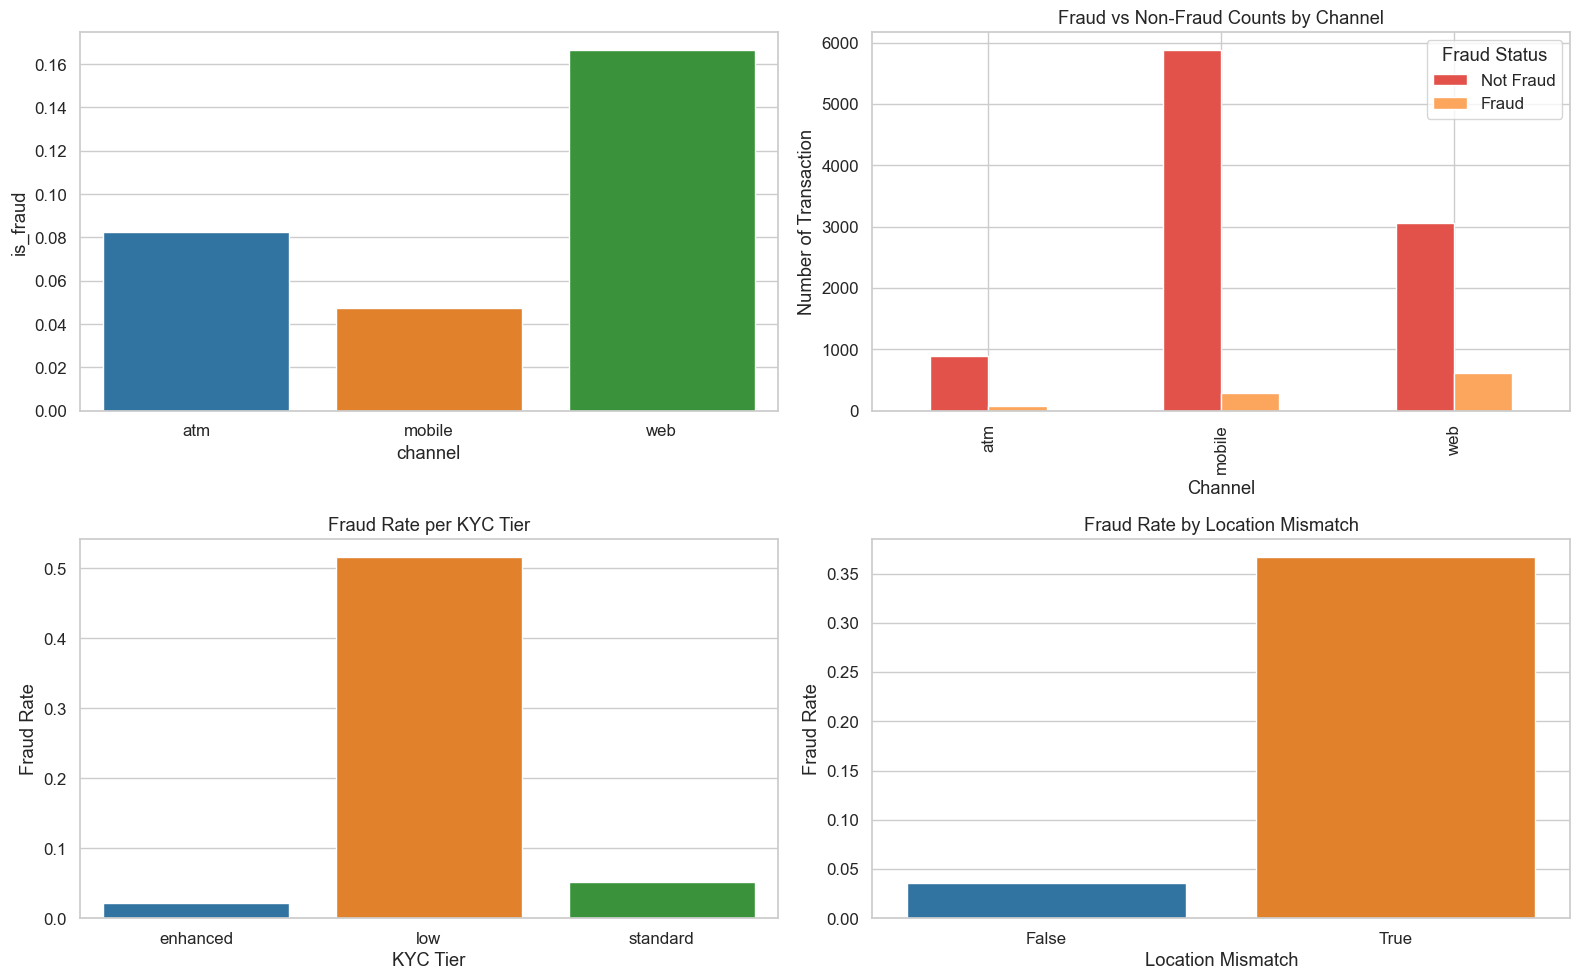

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fraud rate per channel
channel_fraud_rate = cleaned_customer_transaction_data.groupby('channel')['is_fraud'].mean().reset_index()

sns.barplot(
    data=channel_fraud_rate,
    x='channel',
    y='is_fraud',
    ax=axes[0, 0],
    palette='tab10'
)
axes[1, 0].set_title('Fraud Rate per Channel')
axes[1, 0].set_xlabel('Channel')
axes[1, 0].set_ylabel('Fraud Rate')


# Fraud vs Non-Fraud counts per channel
channel_counts = (
    cleaned_customer_transaction_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

channel_counts = channel_counts.rename(
    columns={0: 'Not Fraud', 1: 'Fraud'}
)

channel_counts.plot(
    x='channel',
    y=['Not Fraud', 'Fraud'],
    kind='bar',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Fraud vs Non-Fraud Counts by Channel')
axes[0, 1].set_xlabel('Channel')
axes[0, 1].set_ylabel('Number of Transaction')
axes[0, 1].legend(title='Fraud Status')


# Fraud rate per KYC tier
kyc_fraud_rate = cleaned_customer_transaction_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y='is_fraud',
    ax=axes[1, 0],
    palette='tab10'
)

axes[1, 0].set_title('Fraud Rate per KYC Tier')
axes[1, 0].set_xlabel('KYC Tier')
axes[1, 0].set_ylabel('Fraud Rate')


# Fraud rate per location mismatch
location_fraud_rate = (
    cleaned_customer_transaction_data.groupby('location_mismatch')['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=location_fraud_rate,
    x='location_mismatch',
    y='is_fraud',
    ax=axes[1, 1],
    palette='tab10'
)

axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show() 
 
 

Transaction Velocity and Fraud Risk

The provide code calculate the mean fraud rate (is_fraud) frouped by transaction frequency over 1-hour and 24-hour windows, generating two line plots to examine how transaction velocity correelates with fraud risk.

1-Hour Transaction Velocity (txn_velocity)

* Baseline Behaviour: Account performing standard transaction volumes(1 to 2 transaction per hour) display low fraud rates.

* Risk Spikes: Fraud risk increase sharply starting around 3 transaction per hour, reaching high levels (70-80%).

* High-Velocity Burst:  Rapid successive transaction within an hour indicate automated scripts or compromsed account takeover behaviour.

* Tapered Tail: While the rate declines somewhat at higher transaction counts. it remain well above baseline risk levels.


24-Hour Transaction Velocity(txn_velocity_24h)

* Baseline Behaviour : Normal daily activity (0 to 3 transacton per day) yields extremely low fraud probability.

* Moderate-to-High Surge : Fraud risk increase significantly around 5 transaction per (-75% fraud rate).

* Extreme Risk Preak : As daily frequency scales to 10+ transaction per day, the observed fraud rate approaches 100%.

KEY RISK INSIGHTS

* Velocity as a Signal: High transaction frequency across both short(1h) and long(24h) windows serves as a strong behavioural indicator of fraudulent activity.

* Model Threshlds: While velocity features (txn_velocity_1h and txn_velocity_24h) add strng predictive value for machine learning models, exact percentage thresholds reflect dataset specific patterns and should be validated during model evaluation. 


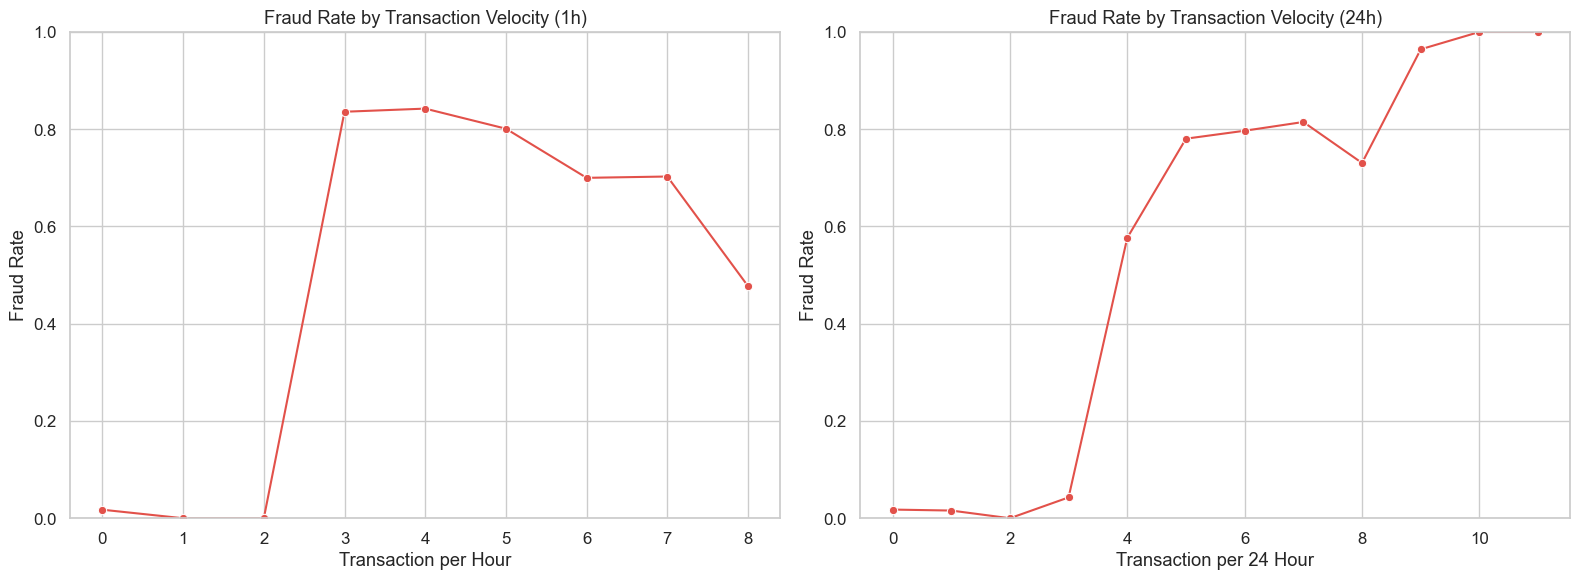

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# 1. Fraud rate by transaction velocity (1 hour)
txn_velocity_1h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_1h,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Fraud Rate by Transaction Velocity (1h)')
axes[0].set_xlabel('Transaction per Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)


# 2. Fraud rate by transaction velocity (24 hour)
txn_velocity_24h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_24h,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Fraud Rate by Transaction Velocity (24h)')
axes[1].set_xlabel('Transaction per 24 Hour')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()  

C:\Users\USER\AppData\Local\Temp\ipykernel_24944\2621677530.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


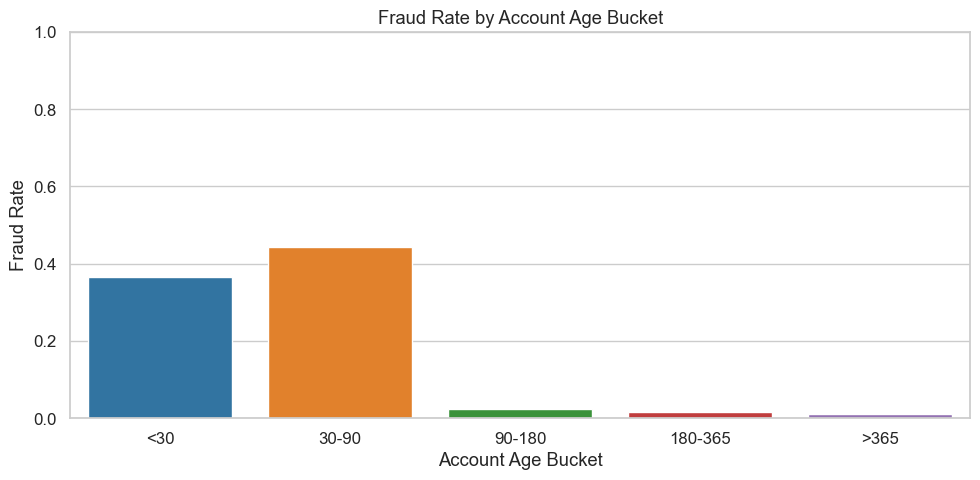

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


# Create account age buckets
cleaned_customer_transaction_data['account_age_bucket'] = pd.cut(
    cleaned_customer_transaction_data['account_age_days'],
    bins=[0, 30, 90, 180, 365, 2000],
    labels=['<30', '30-90', '90-180', '180-365', '>365']
)

# Calculate fraud rate by account age bucket
fraud_rate_account_age = (
    cleaned_customer_transaction_data.groupby('account_age_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_account_age,
    x='account_age_bucket',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0, 1)
plt.title('Fraud Rate by Account Age Bucket')
 

plt.tight_layout()
plt.show()    
 

C:\Users\USER\AppData\Local\Temp\ipykernel_24944\1429280361.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_24944\1429280361.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_24944\1429280361.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


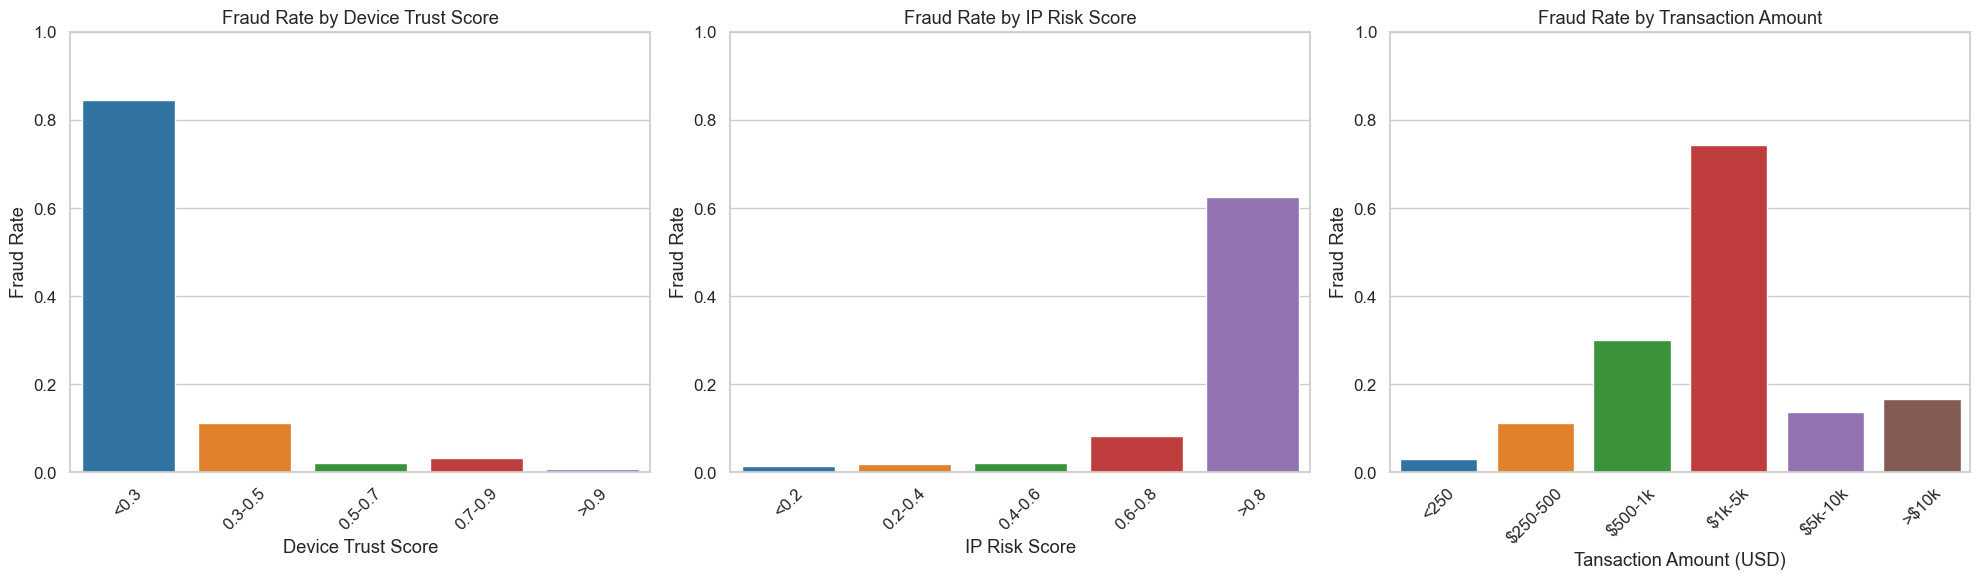

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# 1. Fraud Rate by Device Trust Score

cleaned_customer_transaction_data['device_trust_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
    include_lowest=True
)

fraud_rate_by_device_trust_score = (
    cleaned_customer_transaction_data.groupby(
        'device_trust_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes[0],
    palette='tab10'
)

axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0,1)
axes[0].set_title('Fraud Rate by Device Trust Score')
axes[0].tick_params(axis='x', rotation=45)


# 2. Fraud Rate by IP Risk Score

cleaned_customer_transaction_data['ip_risk_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
)

fraud_rate_by_ip_risk_score = (
    cleaned_customer_transaction_data.groupby(
        'ip_risk_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes[1],
    palette='tab10',
    legend=False
)

axes[1].set_xlabel('IP Risk Score')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0,1)
axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].tick_params(axis='x', rotation=45)


# 3. Fraud Rate by Transaction Amount

cleaned_customer_transaction_data['amount_usd_bucket'] = pd.cut(
    cleaned_customer_transaction_data['amount_usd'],
    bins=[0, 250, 500, 1000, 5000, 10000, 20000],
    labels=['<250', 
            '$250-500', 
            '$500-1k', 
            '$1k-5k', 
            '$5k-10k',
            '>$10k'
            ],
    include_lowest=True
)

fraud_rate_by_amount_usd = (
    cleaned_customer_transaction_data.groupby(
        'amount_usd_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='is_fraud',
    ax=axes[2],
    palette='tab10'
)

axes[2].set_xlabel('Tansaction Amount (USD)')
axes[2].set_ylabel('Fraud Rate')
axes[2].set_ylim(0,1)
axes[2].set_title('Fraud Rate by Transaction Amount')
axes[2].tick_params(axis='x', rotation=45)


# Final layout

plt.tight_layout()
plt.show()          

In [30]:
cleaned_customer_transaction_data.shape 

(10840, 31)

In [31]:
cleaned_customer_transaction_data.columns 

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'account_age_bucket', 'device_trust_score_bucket',
       'ip_risk_score_bucket', 'amount_usd_bucket'],
      dtype='object')

In [32]:
cleaned_customer_transaction_data = cleaned_customer_transaction_data.drop(columns=['Unnamed: 0']) 

In [33]:
cleaned_customer_transaction_data.columns  

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'account_age_bucket',
       'device_trust_score_bucket', 'ip_risk_score_bucket',
       'amount_usd_bucket'],
      dtype='object')

In [39]:
cleaned_customer_transaction_data.to_csv(r"../Finlora Dataset/artifacts/EDA_Data.csv", index=False)   